# 02-Dimensional Data Modeling (Kimball)

In Lesson 01, we established the physical foundation of the Modern Data Stack by implementing an ELT (Extract, Load, Transform) pipeline. We extracted raw, nested JSON strings directly into our staging database, creating our raw **Bronze** table layer, and flattened it into a conformed **Silver** layer.

However, a raw tabular table structure is highly inefficient for corporate analytical computation. If an executive wants to query corporate metrics over a 5-year period, running complex multi-column string operations or full-table scans across hundreds of millions of raw records will trigger massive I/O bottlenecks, causing query execution to stall.

To achieve lightning-fast sub-second analytics over petabyte-scale warehouses, we must abandon transactional application modeling (Third Normal Form or 3NF) and master the industry-standard architecture of **Ralph Kimball’s Dimensional Data Modeling: The Star Schema**.

Let's set up our local OLAP engine to architect this high-performance topological memory structure.

In [1]:
# Required installations: pip install duckdb pandas matplotlib seaborn
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ OLAP Warehouse Warehouse Architecture Engine Operational.")

✅ OLAP Warehouse Warehouse Architecture Engine Operational.


# 1. The Mathematics of Data Cube Geometry

In transactional databases (OLTP), data is normalized to eliminate redundancy. In analytical databases (OLAP), we intentionally de-normalize data to optimize for **join reduction** and **vectorized column scans**.

Kimball modeling partitions an Enterprise's metrics into a rigorous mathematical graph composed of two distinct structures: **Fact Tables** and **Dimension Tables**.

### 1. The Fact Table ($\mathbf{F}$)

The Fact table represents a dense, continuous vector stream of atomic business events or measurements. It contains quantitative, numeric values known as **Measures** (e.g., dollar amounts, item quantities) and foreign keys mapping out to the surrounding contextual dimensions.

Mathematically, a row in a Fact table can be viewed as an entry in a sparse multi-dimensional tensor:


$$\mathbf{f} = \begin{bmatrix} k_1 & k_2 & \dots & k_n & \mid & m_1 & m_2 & \dots & m_m \end{bmatrix}$$


Where $k_i \in \mathbf{K}$ represents a foreign key pointing to a dimension, and $m_j \in \mathbf{M}$ represents an additive numerical metric.

### 2. The Dimension Table ($\mathbf{D}$)

Dimension tables provide the dense descriptive text attributes (the "Who, What, Where, When, and Why") that slice and filter the Fact metrics. Crucially, Dimension tables utilize an integer-based **Surrogate Key** rather than an operational Business Key (like an email or alphanumeric UUID). This mathematically insulates the analytics warehouse from changes or deletions in the source application's production database.

By aligning our data into a **Star Schema**—where a central Fact table is directly surrounded by radially connected Dimension tables—we guarantee that any query can resolve its values in a maximum of **one join layer**, forcing the database compiler to execute highly optimized hash joins.

# 2. Architecting the Star Schema Warehouse

Let's physically implement a complete Kimball Star Schema inside DuckDB. We will ingest a raw, transactional log containing enterprise sales. We will extract the contextual metadata into isolated dimensions (**`dim_users`**, **`dim_products`**) utilizing sequential integer Surrogate Keys, and construct a highly optimized, lean **`fact_sales`** table.

In [2]:
# Initialize our analytical warehouse instance
conn = duckdb.connect('kimball_warehouse.db')

# --- 🪵 STEP 1: Ingest Transactional Log (Simulation of Bronze/Silver Raw Layer) ---
conn.execute("DROP TABLE IF EXISTS silver_raw_transactions;")
conn.execute("""
    CREATE TABLE silver_raw_transactions (
        txn_id VARCHAR,
        user_email VARCHAR,
        user_city VARCHAR,
        product_sku VARCHAR,
        product_name VARCHAR,
        product_category VARCHAR,
        sale_amount DOUBLE,
        quantity INT,
        timestamp TIMESTAMP
    );
""")

# Ingest explicit, highly redundant raw production event tracking data
conn.execute("""
    INSERT INTO silver_raw_transactions VALUES
    ('TXN-001', 'aris@enterprise.com', 'Ankara', 'SKU-99', 'AI Accelerator Card', 'Hardware', 1500.00, 1, '2026-06-24 10:00:00'),
    ('TXN-002', 'bob@cloud.com', 'Istanbul', 'SKU-99', 'AI Accelerator Card', 'Hardware', 3000.00, 2, '2026-06-24 11:15:00'),
    ('TXN-003', 'aris@enterprise.com', 'Ankara', 'SKU-42', 'Vector Embedding API', 'SaaS', 45.00, 1, '2026-06-24 12:00:00');
""")

print("--- 🪵 Transactional Silver Table State (Highly Redundant String Storage) ---")
print(conn.execute("SELECT txn_id, user_email, product_sku, sale_amount FROM silver_raw_transactions").df().to_string())

--- 🪵 Transactional Silver Table State (Highly Redundant String Storage) ---
    txn_id           user_email product_sku  sale_amount
0  TXN-001  aris@enterprise.com      SKU-99       1500.0
1  TXN-002        bob@cloud.com      SKU-99       3000.0
2  TXN-003  aris@enterprise.com      SKU-42         45.0


Now, we execute the transformation algorithms to generate our **Gold Layer: Dimensional Star Schema Model**.

In [3]:
# --- 📐 STEP 2: Engineer Dimension tables with Surrogate Keys ---
print("\n--- 📐 Materializing Dimension Tables ---")

# 1. Create User Dimension
conn.execute("DROP TABLE IF EXISTS dim_users;")
conn.execute("""
    CREATE TABLE dim_users AS
    SELECT 
        -- Natively generate a sequential integer Surrogate Key
        row_number() OVER () AS user_hk, 
        user_email AS operational_email,
        user_city AS city
    FROM (SELECT DISTINCT user_email, user_city FROM silver_raw_transactions);
""")

# 2. Create Product Dimension
conn.execute("DROP TABLE IF EXISTS dim_products;")
conn.execute("""
    CREATE TABLE dim_products AS
    SELECT 
        row_number() OVER () AS product_hk,
        product_sku AS operational_sku,
        product_name AS product_name,
        product_category AS category
    FROM (SELECT DISTINCT product_sku, product_name, product_category FROM silver_raw_transactions);
""")

print("✅ Dimension Tables Materialized. Structural Integrity Enforced.")
print("\n[dim_users Table Structure]:")
print(conn.execute("SELECT * FROM dim_users").df().to_string())
print("\n[dim_products Table Structure]:")
print(conn.execute("SELECT * FROM dim_products").df().to_string())


--- 📐 Materializing Dimension Tables ---
✅ Dimension Tables Materialized. Structural Integrity Enforced.

[dim_users Table Structure]:
   user_hk    operational_email      city
0        1  aris@enterprise.com    Ankara
1        2        bob@cloud.com  Istanbul

[dim_products Table Structure]:
   product_hk operational_sku          product_name  category
0           1          SKU-99   AI Accelerator Card  Hardware
1           2          SKU-42  Vector Embedding API      SaaS


Finally, we construct the centralized Fact table by mapping the messy operational string keys back to our highly efficient integer keys.

In [4]:
# --- 🎯 STEP 3: Engineer Centralized Fact Table ---
print("\n--- 🎯 Materializing Central Fact Table ---")

conn.execute("DROP TABLE IF EXISTS fact_sales;")
conn.execute("""
    CREATE TABLE fact_sales AS
    SELECT 
        -- Extract the light integer Surrogate Keys via Hash Joins
        u.user_hk,
        p.product_hk,
        
        -- Degenerate Dimension (Operational Key preserved for audit lineage)
        t.txn_id,
        
        -- Numeric Additive Metrics (The Tensors of Measurement)
        t.sale_amount,
        t.quantity,
        t.timestamp
    FROM silver_raw_transactions t
    JOIN dim_users u ON t.user_email = u.operational_email
    JOIN dim_products p ON t.product_sku = p.operational_sku;
""")

print("✅ Centralized Fact Table Materialized.")
print("\n[fact_sales Table Structure (Notice it contains only keys and numbers)]:")
print(conn.execute("SELECT * FROM fact_sales").df().to_string())


--- 🎯 Materializing Central Fact Table ---
✅ Centralized Fact Table Materialized.

[fact_sales Table Structure (Notice it contains only keys and numbers)]:
   user_hk  product_hk   txn_id  sale_amount  quantity           timestamp
0        1           1  TXN-001       1500.0         1 2026-06-24 10:00:00
1        2           1  TXN-002       3000.0         2 2026-06-24 11:15:00
2        1           2  TXN-003         45.0         1 2026-06-24 12:00:00


# 3. Executing Sub-Second Analytical Aggregations

Now that our database memory structure has collapsed into a Star Schema, look at how clear, declarative, and computational the analytical operations become.

If an executive wants to evaluate total sales by city for the 'Hardware' category, the query uses clean math over integers rather than full text parsing scans.

In [5]:
print("\n--- 🚀 Running High-Performance Analytical Join Pipeline ---")

analytical_query = """
    SELECT 
        u.city,
        SUM(f.sale_amount) AS total_revenue_usd,
        SUM(f.quantity) AS units_sold
    FROM fact_sales f
    JOIN dim_users u ON f.user_hk = u.user_hk
    JOIN dim_products p ON f.product_hk = p.product_hk
    WHERE p.category = 'Hardware'
    GROUP BY u.city
    ORDER BY total_revenue_usd DESC;
"""

result_df = conn.execute(analytical_query).df()
print("\n[Executive BI Result Output]:")
print(result_df.to_string())

print("\n--- 💡 Engineering Insight ---")
print("Analyze the schema memory optimization. In the raw table, the string 'Hardware' and 'aris@enterprise.com' were repeated across every single row. If we had 100 million transactions, storing those duplicate strings inside our transaction data table would consume gigabytes of useless disk and network I/O.")
print("In our Kimball Star Schema, the central Fact table contains exclusively numbers: light 4-byte integers for foreign keys and floats for metrics. The string records are completely isolated inside tiny dimension sidecar tables. The underlying database engine can now run vectorized bitmask operations over the integer columns, achieving maximum computational throughput.")


--- 🚀 Running High-Performance Analytical Join Pipeline ---

[Executive BI Result Output]:
       city  total_revenue_usd  units_sold
0  Istanbul             3000.0         2.0
1    Ankara             1500.0         1.0

--- 💡 Engineering Insight ---
Analyze the schema memory optimization. In the raw table, the string 'Hardware' and 'aris@enterprise.com' were repeated across every single row. If we had 100 million transactions, storing those duplicate strings inside our transaction data table would consume gigabytes of useless disk and network I/O.
In our Kimball Star Schema, the central Fact table contains exclusively numbers: light 4-byte integers for foreign keys and floats for metrics. The string records are completely isolated inside tiny dimension sidecar tables. The underlying database engine can now run vectorized bitmask operations over the integer columns, achieving maximum computational throughput.


# 4. Visualizing the Topological Star Graph

To understand why this architecture is structurally optimized for database compilers, let's visualize the graph topology of our warehouse. Notice the clean radial alignment compared to the tangled relationships typical of un-modeled transactional tables.

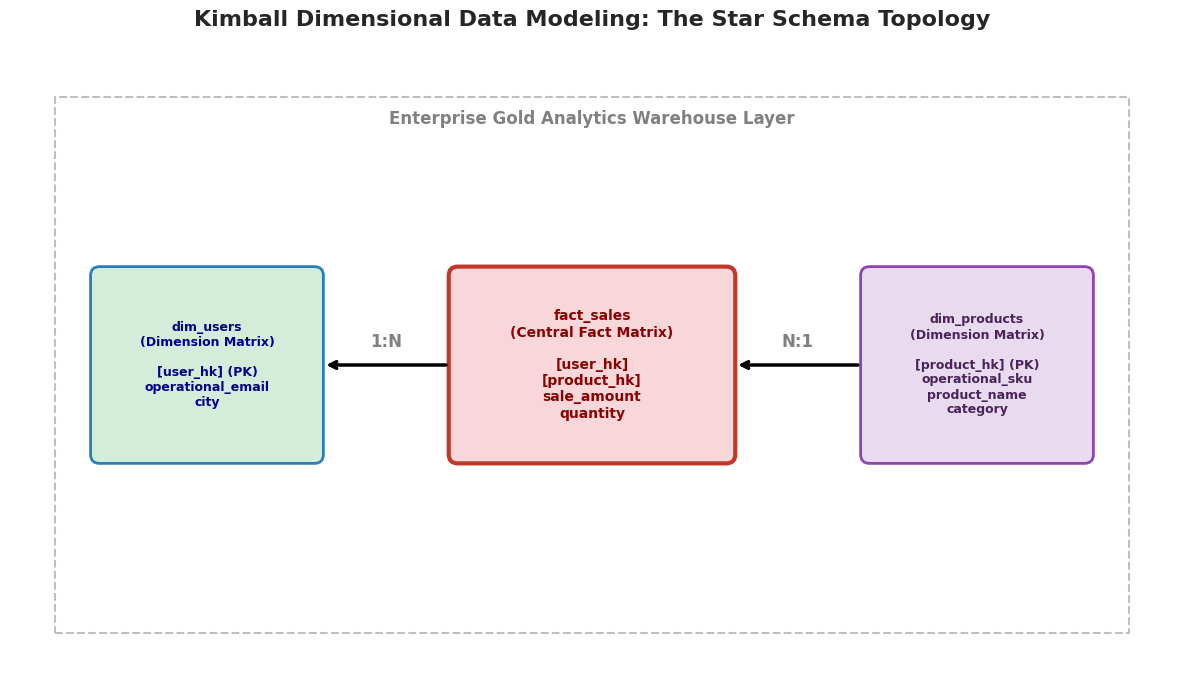

In [6]:
# Visualizing the Star Schema Graph Topology
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Kimball Dimensional Data Modeling: The Star Schema Topology", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Central Fact Table (The Hub)
fact_box = patches.FancyBboxPatch((4.5, 2.5), 3.0, 2.0, boxstyle="round,pad=0.1", 
                                  linewidth=3, edgecolor='#c0392b', facecolor='#f8d7da', zorder=3)
ax.add_patch(fact_box)
ax.text(6, 3.5, "fact_sales\n(Central Fact Matrix)\n\n[user_hk]\n[product_hk]\nsale_amount\nquantity", 
        ha='center', va='center', fontweight='bold', color='darkred', fontsize=10)

# 2. Sidecar Dimensions (The Spokes)
# User Dimension (Left Side)
dim_user_box = patches.FancyBboxPatch((0.5, 2.5), 2.4, 2.0, boxstyle="round,pad=0.1", 
                                      linewidth=2, edgecolor='#2980b9', facecolor='#d4edda', zorder=3)
ax.add_patch(dim_user_box)
ax.text(1.7, 3.5, "dim_users\n(Dimension Matrix)\n\n[user_hk] (PK)\noperational_email\ncity", 
        ha='center', va='center', fontweight='bold', color='darkblue', fontsize=9)

# Product Dimension (Right Side)
dim_prod_box = patches.FancyBboxPatch((9.1, 2.5), 2.4, 2.0, boxstyle="round,pad=0.1", 
                                      linewidth=2, edgecolor='#8e44ad', facecolor='#e8daef', zorder=3)
ax.add_patch(dim_prod_box)
ax.text(10.3, 3.5, "dim_products\n(Dimension Matrix)\n\n[product_hk] (PK)\noperational_sku\nproduct_name\ncategory", 
        ha='center', va='center', fontweight='bold', color='#4a235a', fontsize=9)

# 3. Draw the Relational Edges
# dim_users -> fact_sales
ax.annotate("", xy=(4.4, 3.5), xytext=(3.0, 3.5), 
            arrowprops=dict(arrowstyle="<-", color="black", lw=2.5, linestyle="solid"))
ax.text(3.7, 3.7, "1:N", ha='center', fontweight='bold', color='gray')

# dim_products -> fact_sales
ax.annotate("", xy=(7.6, 3.5), xytext=(9.0, 3.5), 
            arrowprops=dict(arrowstyle="->", color="black", lw=2.5, linestyle="solid"))
ax.text(8.3, 3.7, "N:1", ha='center', fontweight='bold', color='gray')

# Draw background data warehouse boundaries
ax.add_patch(patches.Rectangle((0, 0.5), 12, 6, fill=False, edgecolor='gray', linestyle='--', linewidth=1.5, alpha=0.5))
ax.text(6, 6.2, "Enterprise Gold Analytics Warehouse Layer", ha='center', fontweight='bold', color='gray', fontsize=12)

plt.xlim(-0.5, 12.5)
plt.ylim(0, 7)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between an application table and a Kimball Star Schema like **Navigating an Grocery Store**:

* **Transactional Modeling (The Dynamic Cargo Heap)**: Imagine a store where items are stacked randomly in boxes exactly as they arrive on delivery trucks. Eggs are mixed with sweeping brooms, and milk cartons are buried under bags of coal. If a customer (the analytical query) wants to find all "Organic Dairy Products," they must physically rip open every single box in the entire warehouse and scan every item line-by-line. This is a full-table scan bottleneck.
* **Dimensional Modeling (The Organized Star Supermarket)**: The supermarket is engineered for speed. The center of the store features **The Cash Register (The Central Fact Table)**, tracking clean numerical arrays of transaction transactions. Radial pathways lead outwards to strictly categorized, labeled aisles **(The Dimension Tables)**: Aisle 1 is exclusively Users, and Aisle 2 is exclusively Products.
* If you want to calculate how much money the store made on Organic Dairy in Ankara, you go instantly to Aisle 2 to filter the target product IDs, skip across to the cash register to fetch the quantitative revenue figures, and you are done in seconds without ever touching the rest of the store.